In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/joshthegreat/customer-sales-dataset-v2/sales_data.csv


In [2]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Customer Segmentation Analysis — RFM + KMeans Clustering

## Project Overview

This notebook applies **RFM Analysis** and **KMeans Clustering** to segment 
customers of an e-commerce business into distinct behavioural groups. 

The goal is to enable targeted marketing strategies by identifying which 
customers are Champions, which are at risk, and which have been lost — 
so the business can treat each group appropriately.

**Tech Stack:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

In [3]:
df = pd.read_csv('/kaggle/input/datasets/joshthegreat/customer-sales-dataset-v2/sales_data.csv')
df

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Price,Unit Cost
0,SO - 000101,In-Store,WARE-UHY1004,12/31/2017,5/31/2018,6/14/2018,6/19/2018,USD,6,15,259,12,5,0.075,1963.1,1001.181
1,SO - 000102,Online,WARE-NMK1003,12/31/2017,5/31/2018,6/22/2018,7/2/2018,USD,14,20,196,27,3,0.075,3939.6,3348.660
2,SO - 000103,Distributor,WARE-UHY1004,12/31/2017,5/31/2018,6/21/2018,7/1/2018,USD,21,16,213,16,1,0.050,1775.5,781.220
3,SO - 000104,Wholesale,WARE-NMK1003,12/31/2017,5/31/2018,6/2/2018,6/7/2018,USD,28,48,107,23,8,0.075,2324.9,1464.687
4,SO - 000105,Distributor,WARE-NMK1003,4/10/2018,5/31/2018,6/16/2018,6/26/2018,USD,22,49,111,26,8,0.100,1822.4,1476.144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7986,SO - 0008087,In-Store,WARE-MKL1006,9/26/2020,12/30/2020,1/7/2021,1/14/2021,USD,9,41,339,29,1,0.075,234.5,121.940
7987,SO - 0008088,Online,WARE-NMK1003,9/26/2020,12/30/2020,1/2/2021,1/4/2021,USD,14,29,202,3,6,0.050,3202.6,1921.560
7988,SO - 0008089,Online,WARE-UHY1004,9/26/2020,12/30/2020,1/23/2021,1/26/2021,USD,14,32,241,35,5,0.200,3825.7,2792.761
7989,SO - 0008090,Online,WARE-NMK1003,9/26/2020,12/30/2020,1/20/2021,1/25/2021,USD,20,42,112,36,8,0.100,1072.0,804.000


In [4]:
df.columns = df.columns.str.replace('_','')
print(df.shape)
print(df.head())

(7991, 16)
   OrderNumber Sales Channel WarehouseCode ProcuredDate  OrderDate   ShipDate  \
0  SO - 000101      In-Store  WARE-UHY1004   12/31/2017  5/31/2018  6/14/2018   
1  SO - 000102        Online  WARE-NMK1003   12/31/2017  5/31/2018  6/22/2018   
2  SO - 000103   Distributor  WARE-UHY1004   12/31/2017  5/31/2018  6/21/2018   
3  SO - 000104     Wholesale  WARE-NMK1003   12/31/2017  5/31/2018   6/2/2018   
4  SO - 000105   Distributor  WARE-NMK1003    4/10/2018  5/31/2018  6/16/2018   

  DeliveryDate CurrencyCode  SalesTeamID  CustomerID  StoreID  ProductID  \
0    6/19/2018          USD            6          15      259         12   
1     7/2/2018          USD           14          20      196         27   
2     7/1/2018          USD           21          16      213         16   
3     6/7/2018          USD           28          48      107         23   
4    6/26/2018          USD           22          49      111         26   

   Order Quantity  Discount Applied  Unit Pri

In [5]:
#Checking for num values and duplicates
print(df.isnull().sum())
print(df.duplicated().sum())

OrderNumber         0
Sales Channel       0
WarehouseCode       0
ProcuredDate        0
OrderDate           0
ShipDate            0
DeliveryDate        0
CurrencyCode        0
SalesTeamID         0
CustomerID          0
StoreID             0
ProductID           0
Order Quantity      0
Discount Applied    0
Unit Price          0
Unit Cost           0
dtype: int64
0


## 1. Data Loading & Inspection

The dataset was successfully loaded and inspected:

- **No missing values** found across any column
- **No duplicate rows** detected
- The dataset is clean and ready for preprocessing

Key columns for this analysis: CustomerID, OrderDate, OrderNumber, 
Unit Price, Unit Cost, Discount Applied, Order Quantity

In [6]:
#Correcting the datatypes
df['CustomerID'] = df['CustomerID'].astype(str)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['ShipDate'] = pd.to_datetime(df['ShipDate'])
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])
print(df.dtypes)

OrderNumber                 object
Sales Channel               object
WarehouseCode               object
ProcuredDate                object
OrderDate           datetime64[ns]
ShipDate            datetime64[ns]
DeliveryDate        datetime64[ns]
CurrencyCode                object
SalesTeamID                  int64
CustomerID                  object
StoreID                      int64
ProductID                    int64
Order Quantity               int64
Discount Applied           float64
Unit Price                 float64
Unit Cost                  float64
dtype: object


## 2. Data Cleaning & Type Corrections

The following data type corrections were applied:

- **CustomerID** → converted to string (it is an identifier, not a number)
- **OrderDate, ShipDate, DeliveryDate** → converted to datetime for accurate 
  date-based calculations

Column names were also standardised by removing underscores for cleaner referencing.

In [7]:
#Creating the revenue column
df['revenue'] = (df['Unit Price']-(df['Unit Price']*df['Discount Applied'])-df['Unit Cost'])*df['Order Quantity']
columns = ['OrderNumber', 'CustomerID', 'OrderDate', 'revenue']
df_dataset = df[columns]

## 3. Feature Engineering — Revenue Calculation

A **revenue** column was engineered using the formula:

> Revenue = (Unit Price − (Unit Price × Discount) − Unit Cost) × Order Quantity

This calculates **actual profit per order** rather than gross sales — giving a 
more accurate picture of each customer's true value to the business.

Only four columns are retained for RFM computation: 
OrderNumber, CustomerID, OrderDate, Revenue.

In [8]:
#Getting the recency, frequency and monteary values of the customers
today = pd.to_datetime('2021-01-01')
rfm_dataset = df_dataset.groupby('CustomerID').agg({
    'OrderDate'  : lambda x: (today-x.max()).days,
    'OrderNumber' : 'count',
    'revenue' : 'sum'
})
print(rfm_dataset.head(10))

            OrderDate  OrderNumber      revenue
CustomerID                                     
1                   9          152  335933.6115
10                 15          158  435122.1870
11                  6          178  487614.2415
12                  3          210  616719.2550
13                  4          171  441003.2795
14                  5          157  381450.0280
15                  4          142  441668.3550
16                  3          135  402938.7705
17                  6          175  534027.3860
18                  6          186  451637.7540


In [9]:
rfm_dataset.rename(columns = {
    'OrderDate' : 'Recency',
    'OrderNumber': 'Frequency',
    'revenue': 'Monetary value'
}, inplace=True)
print(rfm_dataset.head(10))

            Recency  Frequency  Monetary value
CustomerID                                    
1                 9        152     335933.6115
10               15        158     435122.1870
11                6        178     487614.2415
12                3        210     616719.2550
13                4        171     441003.2795
14                5        157     381450.0280
15                4        142     441668.3550
16                3        135     402938.7705
17                6        175     534027.3860
18                6        186     451637.7540


## 4. RFM Feature Computation

Each customer was aggregated into three behavioural dimensions:

| Feature | Definition |
|---|---|
| **Recency** | Days since last purchase (lower = more recent = better) |
| **Frequency** | Total number of orders placed |
| **Monetary Value** | Total profit generated by the customer |

Reference date used: **2021-01-01** (one day after the last transaction date 
in the dataset to ensure all customers have a recency value greater than 0).

In [10]:
#Scaling the data
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
Scaled = Scaler.fit_transform(rfm_dataset)
print(Scaled)

[[ 0.35571544 -0.55508813 -1.47975444]
 [ 1.47902735 -0.12918931  0.14075991]
 [-0.20594052  1.29047344  0.99835996]
 [-0.76759647  3.56193384  3.10764044]
 [-0.58037782  0.79359148  0.2368435 ]
 [-0.39315917 -0.20017245 -0.73612035]
 [-0.58037782 -1.26491951  0.24770931]
 [-0.76759647 -1.76180147 -0.38504347]
 [-0.20594052  1.07752403  1.75664453]
 [-0.20594052  1.85833854  0.41058648]
 [-0.76759647  0.36769265  0.27325297]
 [ 0.35571544 -1.76180147 -1.61902489]
 [ 0.35571544  0.50965893  0.20653164]
 [-0.76759647  0.29670951  0.86388178]
 [-0.58037782 -1.40688578 -0.40492627]
 [ 0.9173714   0.29670951  0.38027243]
 [ 2.97677657 -0.62607127 -1.20900729]
 [-0.39315917  0.15474324  0.57337936]
 [ 0.73015274 -0.484105   -0.82897315]
 [-0.76759647 -1.12295323 -1.46298914]
 [ 0.16849679 -1.0519701  -1.27452234]
 [-0.95481513  1.36145658  1.71977531]
 [ 0.54293409  1.50342285  0.64882924]
 [-0.58037782 -0.05820617  0.25921165]
 [-0.58037782 -0.55508813 -0.45565401]
 [-0.95481513  0.93555775

## 5. Data Normalisation — StandardScaler

Before applying KMeans clustering, the RFM features were **standardised** 
using StandardScaler.

**Why normalisation is necessary:**

KMeans clustering calculates distances between data points. If features are 
on different scales — for example Recency in hundreds of days vs Frequency 
in single digits — the algorithm will be dominated by the larger-scale feature 
and produce biased clusters.

StandardScaler transforms each feature to have:
- **Mean = 0**
- **Standard deviation = 1**

This ensures all three RFM dimensions contribute equally to the clustering.

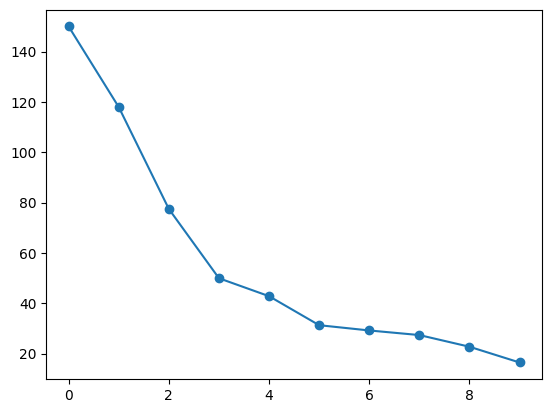

In [11]:
#Using Elbow method to determine the number of clusters
from sklearn.cluster import KMeans
inertia = []
for i in np.arange(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(Scaled)
    inertia.append(kmeans.inertia_)
    
plt.plot(inertia, marker='o')

## 6. Elbow Method — Finding Optimal Number of Clusters

The Elbow Method plots the **inertia** (sum of squared distances from each 
point to its cluster centre) for K values from 1 to 10.

The optimal K is found at the "elbow" — the point where inertia stops 
decreasing sharply and begins to flatten out.

Based on the elbow plot, **K = 4** was selected as the optimal number of 
clusters, balancing model complexity with meaningful customer segmentation.

In [12]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
kmeans.fit(Scaled)
rfm_dataset['clusters'] = kmeans.labels_
print(rfm_dataset.head(10))

            Recency  Frequency  Monetary value  clusters
CustomerID                                              
1                 9        152     335933.6115         2
10               15        158     435122.1870         0
11                6        178     487614.2415         1
12                3        210     616719.2550         3
13                4        171     441003.2795         1
14                5        157     381450.0280         2
15                4        142     441668.3550         2
16                3        135     402938.7705         2
17                6        175     534027.3860         1
18                6        186     451637.7540         1


## 7. KMeans Clustering — K = 4

KMeans was applied with 4 clusters. Each customer was assigned to one of 
four groups based on their normalised RFM values.

The cluster labels (0, 1, 2, 3) are numeric by default — they will be 
mapped to meaningful business segment names in a later step.

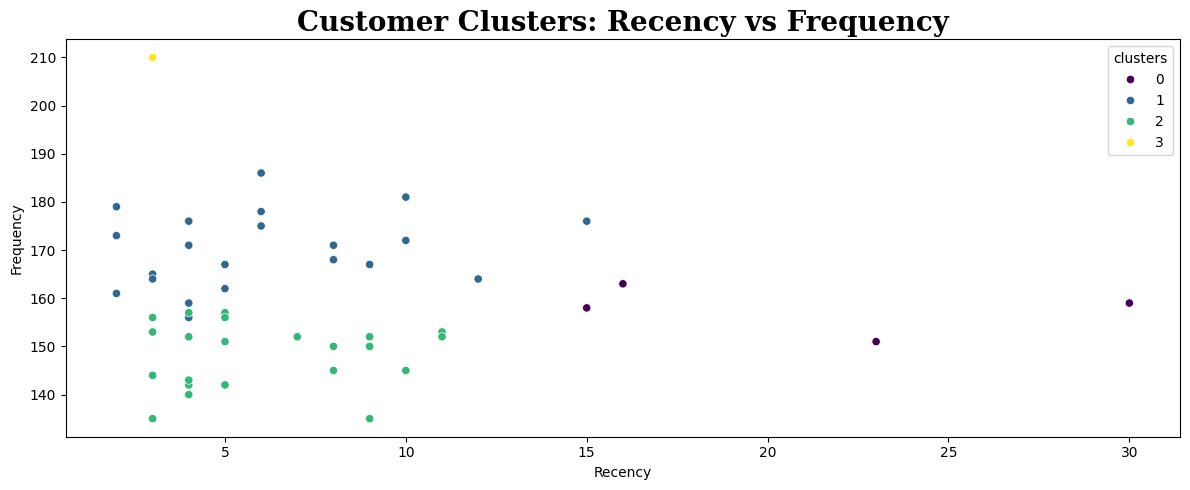

In [13]:
#Scatter plot of customer clusters in relation to recency and frequency
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=rfm_dataset,
    x='Recency',
    y='Frequency',
    hue='clusters',
    palette='viridis'
)
font1 = {"family":"serif", "size":"20", "weight":"bold"}
plt.title("Customer Clusters: Recency vs Frequency", fontdict=font1)
plt.tight_layout()
plt.show()

## 8. Cluster Visualisation — Recency vs Frequency

The scatter plot above shows how customers are distributed across the 
4 clusters when plotted on Recency (x-axis) vs Frequency (y-axis).

Clusters that appear in the **bottom-right** (low recency, high frequency) 
represent the most engaged recent buyers. Clusters in the **top-left** 
(high recency, low frequency) represent disengaged or lost customers.

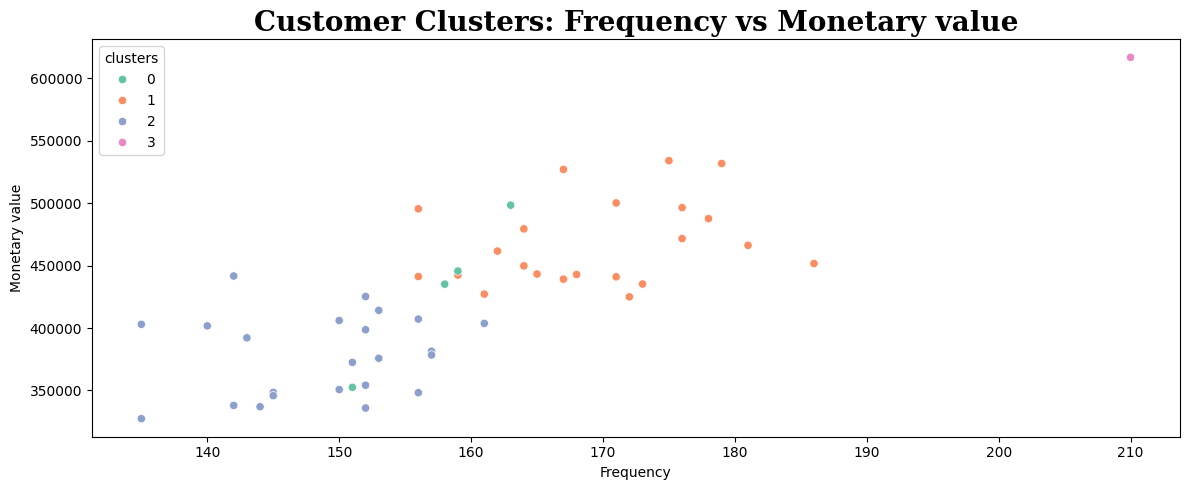

In [14]:
#Scatter plot of customer clusters in relation to frequency vs monetary value
plt.figure(figsize=(12,5))
sns.scatterplot(
    data=rfm_dataset,
    x='Frequency',
    y='Monetary value',
    hue='clusters',
    palette='Set2'
)
font1 = {"family":"serif", "size":"20", "weight":"bold"}
plt.title("Customer Clusters: Frequency vs Monetary value", fontdict=font1)
plt.tight_layout()
plt.show()

## 9. Cluster Visualisation — Frequency vs Monetary Value

This scatter plot reveals the relationship between how often customers 
buy (Frequency) and how much profit they generate (Monetary Value).

Customers in the **top-right** are high-frequency, high-value — your 
most profitable segment. Customers in the **bottom-left** are infrequent, 
low-value buyers requiring re-engagement strategies.

In [15]:
cluster_profile = rfm_dataset.groupby('clusters')[['Recency', 'Frequency', 'Monetary value']].mean()
print(cluster_profile)

            Recency   Frequency  Monetary value
clusters                                       
0         21.000000  157.750000   432911.362875
1          6.000000  169.409091   467719.084864
2          5.913043  148.826087   377701.851370
3          3.000000  210.000000   616719.255000


## 10. Cluster Profiling

The table above shows the average Recency, Frequency, and Monetary Value 
for each cluster:

| Cluster | Avg Recency | Avg Frequency | Avg Monetary Value | Interpretation |
|---|---|---|---|---|
| 0 | 21.0 days | 157.8 orders | $432,911 | Longest since last purchase — disengaging |
| 1 | 6.0 days | 169.4 orders | $467,719 | Recently active, high value |
| 2 | 5.9 days | 148.8 orders | $377,702 | Recently active, moderate value |
| 3 | 3.0 days | 210.0 orders | $616,719 | Most recent, most frequent, highest value |

This profile guided the segment naming in the next step — higher scores 
across all three dimensions indicate a more valuable customer relationship.

In [16]:
rfm_dataset = rfm_dataset.reset_index()
profiles = {
    0: 'At Risk',        # Highest recency (21 days), lowest freq & value
    1: 'Champions',      # Low recency (6 days), high freq & value
    2: 'Regular Customers',  # Low recency (5.9 days), moderate freq & value
    3: 'VIP'     # Lowest recency (3 days), highest freq & value
}
rfm_dataset['Segment'] = rfm_dataset['clusters'].map(profiles)
segment_summary = rfm_dataset.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary value':'mean',
    'CustomerID':'count'
})

print(segment_summary)

                     Recency   Frequency  Monetary value  CustomerID
Segment                                                             
At Risk            21.000000  157.750000   432911.362875           4
Champions           6.000000  169.409091   467719.084864          22
Regular Customers   5.913043  148.826087   377701.851370          23
VIP                 3.000000  210.000000   616719.255000           1


## 11. Segment Summary

The 4 clusters were mapped to meaningful business segment names 
based on their actual RFM profiles:

| Segment | Customers | Avg Recency | Avg Frequency | Avg Monetary Value |
|---|---|---|---|---|
| **VIP** | 1 | 3.0 days | 210.0 orders | $616,719 |
| **Champions** | 22 | 6.0 days | 169.4 orders | $467,719 |
| **Regular Customers** | 23 | 5.9 days | 148.8 orders | $377,702 |
| **At Risk** | 4 | 21.0 days | 157.8 orders | $432,911 |

**Key observations:**

- **VIP** is a single customer — an extreme outlier who bought most recently, 
  most frequently, and generated the highest monetary value of any customer 
  in the dataset. This customer alone deserves dedicated retention attention.

- **At Risk** customers have the highest recency (21 days) — significantly 
  longer than Champions and Regular Customers — despite having moderate 
  frequency and monetary value. This signals disengagement from previously 
  active buyers.

- **Champions and Regular Customers** are very similar in recency (6.0 vs 
  5.9 days) — the key differentiator is frequency and monetary value, 
  with Champions outperforming on both dimensions.

In [17]:
#Cluster summary
cluster_summary = (
    rfm_dataset
    .groupby(['clusters', 'Segment'])
    .size()
    .reset_index(name='Customer_Count')
)

print(cluster_summary)

   clusters            Segment  Customer_Count
0         0            At Risk               4
1         1          Champions              22
2         2  Regular Customers              23
3         3                VIP               1


## 12. Customer Distribution per Cluster

Out of 50 total customers:

- **Regular Customers** form the largest segment with 23 customers (46%) — 
  the core customer base with consistent but moderate purchasing behaviour
- **Champions** follow closely with 22 customers (44%) — an unusually high 
  proportion of high-value customers indicating a strong loyal base
- **At Risk** accounts for 4 customers (8%) — small but worth monitoring 
  given their historical monetary value of $432,911 average
- **VIP** is 1 customer (2%) — a single outlier whose RFM scores dwarf 
  every other segment

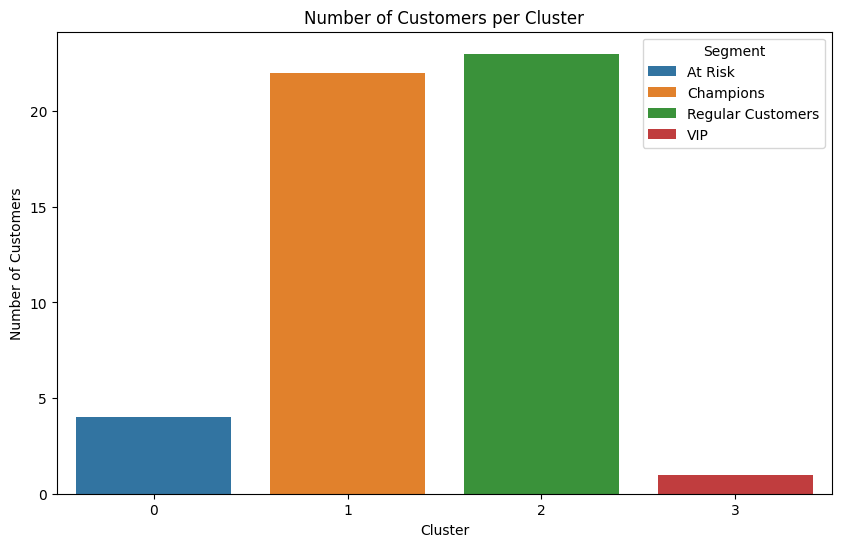

In [18]:
#Number of customer per cluster
plt.figure(figsize=(10,6))

sns.barplot(
    data=cluster_summary,
    x='clusters',
    y='Customer_Count',
    hue='Segment'
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.legend(title="Segment")
plt.show()

## 13. Insights & Marketing Recommendations

### Overview

KMeans clustering with K=4 identified 4 distinct customer segments across 
50 customers. The business has a remarkably strong customer base — 90% of 
customers fall into Champions or Regular Customers, both of which are 
recently active and generating strong revenue. The primary risk is the 
4 At Risk customers who are showing signs of disengagement.

---

### VIP — 1 Customer
**Profile:**
- Average Recency: 3.0 days — most recently active of all segments
- Average Frequency: 210 orders — highest purchase frequency
- Average Monetary Value: $616,719 — highest revenue generator

**What this means:**
This is a single customer who outperforms every other customer across 
all three RFM dimensions. They are effectively in a league of their own. 
Losing this customer would have an outsized negative impact on total revenue.

**Marketing Actions:**
- Assign a **dedicated account manager** — this customer deserves 
  white-glove personal service
- Offer **exclusive first access** to new products, special pricing, 
  and premium experiences unavailable to other segments
- Build a **personal relationship** beyond transactional marketing — 
  check-in calls, birthday recognition, handwritten notes
- **Never let this customer feel like just another number** — 
  personalisation at the highest level is non-negotiable here

---

### Champions — 22 Customers
**Profile:**
- Average Recency: 6.0 days — very recently active
- Average Frequency: 169.4 orders — high purchase rate
- Average Monetary Value: $467,719 — strong revenue contribution

**What this means:**
Champions make up 44% of the customer base and are the engine of the 
business. They buy often, bought recently, and generate significant 
revenue. This is an unusually high proportion of Champions for any 
customer base — a strong indicator of overall customer health.

**Marketing Actions:**
- Enroll in a **VIP loyalty program** with tiered rewards and 
  exclusive perks to maintain engagement
- Request **reviews and referrals** — Champions are the most likely 
  to advocate for the brand and bring in new customers
- Send **personalised appreciation campaigns** acknowledging their 
  loyalty — customers who feel recognised stay longer
- Introduce **early access programmes** for new products to make 
  Champions feel valued before the general public

---

### Regular Customers — 23 Customers
**Profile:**
- Average Recency: 5.9 days — almost identical to Champions
- Average Frequency: 148.8 orders — consistent purchasing behaviour
- Average Monetary Value: $377,702 — solid revenue contribution

**What this means:**
Regular Customers are the largest segment (46%) and are extremely 
close to Champions in recency. The gap between Regular Customers 
and Champions is primarily in frequency and monetary value — not 
engagement. These customers are one targeted campaign away from 
Champion status.

**Marketing Actions:**
- Focus campaigns on **increasing order frequency and basket size** 
  through bundle offers, volume discounts, and cross-sell recommendations
- Show customers their **progress toward Champion tier** — gamification 
  of loyalty drives behaviour change
- Send **personalised product recommendations** based on purchase 
  history to increase average order value per transaction
- These customers represent the greatest **upside opportunity** — 
  converting even half of them to Champions would significantly 
  increase total revenue

---

### At Risk — 4 Customers
**Profile:**
- Average Recency: 21.0 days — longest gap since last purchase
- Average Frequency: 157.8 orders — historically active
- Average Monetary Value: $432,911 — historically strong spenders

**What this means:**
At Risk customers have not purchased in 21 days on average — 3.5x 
longer than Champions. Yet their historical frequency and monetary 
value are strong, confirming these were once active, high-value 
customers who are now disengaging. Time is critical — the longer 
they go without purchasing, the harder they are to win back.

**Marketing Actions:**
- Launch an **immediate personalised win-back campaign** with a 
  compelling time-sensitive offer (e.g. "We miss you — exclusive 
  20% off for the next 7 days only")
- **Do not use generic mass campaigns** — these customers responded 
  to personalised experiences when they were active; only 
  personalisation will win them back
- If no response after **2 targeted attempts**, reassess — continued 
  heavy investment with no response signals they may have churned 
  permanently
- Investigate **why they disengaged** — exit surveys or purchase 
  pattern analysis could reveal product, pricing, or service issues 
  affecting other segments too

---

### Conclusion

This segmentation analysis reveals a customer base that is largely 
healthy — with 90% of customers recently active and generating 
strong revenue. The key findings and priorities are:

1. **The VIP customer is a business-critical asset** — a single 
   customer generating $616,719 in monetary value requires dedicated 
   personal attention and cannot be treated like a regular account.

2. **Champions (44%) are the revenue engine** — retention of this 
   segment through loyalty programmes and personalised recognition 
   should be the top ongoing marketing priority.

3. **Regular Customers (46%) are the biggest growth opportunity** — 
   their proximity to Champion status in recency means a targeted 
   frequency and value campaign could deliver significant revenue uplift.

4. **At Risk customers require immediate action** — 4 customers with 
   historically strong RFM profiles are going quiet. A personalised 
   win-back campaign launched now — before they churn completely — 
   is the single highest-ROI marketing action available to the business.

Implementing these segment-specific strategies rather than blanket 
campaigns has the potential to significantly improve marketing ROI, 
reduce customer churn, and increase overall customer lifetime value.